# 12장 튜닝 기법

* "부록3 매트플롯립 입문"에서 한글 폰트를 올바르게 출력하기 위한 설치 방법을 설명했다. 설치 방법은 다음과 같다.

In [1]:
!sudo apt-get install -y fonts-nanum* | tail -n 1
!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 4.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 39 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no suc

In [2]:
# 필요 라이브러리 설치

!pip install torchviz | tail -n 1
!pip install torchinfo | tail -n 1

* 모든 설치가 끝나면 한글 폰트를 바르게 출력하기 위해 **[런타임]** -> **[런타임 다시시작]**을 클릭한 다음, 아래 셀부터 코드를 실행해 주십시오.

In [1]:
# 라이브러리 임포트

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# 폰트 관련 용도
import matplotlib.font_manager as fm

# 폰트 관련 용도
import matplotlib.font_manager as fm

# Colab, Linux
# 나눔 고딕 폰트의 경로 명시
path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_name = fm.FontProperties(fname=path, size=10).get_name()

# Window
# font_name = "NanumBarunGothic"

# Mac
# font_name = "AppleGothic"


In [2]:
# 파이토치 관련 라이브러리

import torch
from torch import nn, optim
from torchinfo import summary
from torchviz import make_dot
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader


In [3]:
# plt.rcParams.items()

In [4]:
# warning 표시 끄기
import warnings
warnings.simplefilter('ignore')

# 기본 폰트 설정
plt.rcParams['font.family'] = font_name  # window font

# 기본 폰트 사이즈 변경
plt.rcParams['font.size'] = 14

# 기본 그래프 사이즈 변경
plt.rcParams['figure.figsize'] = (6,6)

# 기본 그리드 표시
# 필요에 따라 설정할 때는, plt.grid()
plt.rcParams['axes.grid'] = True
plt.rcParams["grid.linestyle"] = ":"

# 마이너스 기호 정상 출력
plt.rcParams['axes.unicode_minus'] = False

# 넘파이 부동소수점 자릿수 표시
np.set_printoptions(suppress=True, precision=4)

In [5]:
# GPU 디바이스 할당

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [6]:
# 분류 클래스 명칭 리스트
# CIFAR10
classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# 분류 클래스 수,　10
n_output = len(list(set(classes)))
# n_output = len(set(classes))

# 결과 확인
print(n_output)

10


## 과학습의 대응 방법

### 드랍 아웃 함수 동작 확인

In [7]:
# 드랍 아웃 실험용 더미 데이터 작성

torch.manual_seed(123)
inputs = torch.randn(1, 10)
print(inputs)

tensor([[-0.1115,  0.1204, -0.3696, -0.2404, -1.1969,  0.2093, -0.9724, -0.7550,
          0.3239, -0.1085]])


In [8]:
# 드랍 아웃 함수 정의
dropout = nn.Dropout(0.5)

# 훈련 페이즈에서의 거동
dropout.train()
print("dropout.training = ", dropout.training) #
outputs = dropout(inputs)
print(outputs)

# 예측 페이즈에서의 거동
print("="*50)
dropout.eval()
print("dropout.training = ", dropout.training)
outputs = dropout(inputs)
print(outputs)

dropout.training =  True
tensor([[-0.0000,  0.2407, -0.0000, -0.4808, -0.0000,  0.0000, -1.9447, -0.0000,
          0.6478, -0.2170]])
dropout.training =  False
tensor([[-0.1115,  0.1204, -0.3696, -0.2404, -1.1969,  0.2093, -0.9724, -0.7550,
          0.3239, -0.1085]])


## 공통 함수의 라이브러리화

In [9]:
# # 공통 함수 다운로드
!git clone https://github.com/wikibook/pythonlibs.git

# # 공통 함수 불러오기
from pythonlibs.torch_lib1 import *

# # 공통 함수 확인
print(README)

Cloning into 'pythonlibs'...
remote: Enumerating objects: 25, done.
remote: Counting objects: 100% (25/25), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 25 (delta 6), reused 25 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (25/25), 21.10 MiB | 19.24 MiB/s, done.
Resolving deltas: 100% (6/6), done.
Common Library for PyTorch
Author: M. Akaishi


## 데이터 준비

In [10]:
# Transforms의 정의

transform = transforms.Compose([
  transforms.ToTensor(),
  transforms.Normalize(0.5, 0.5)
])

In [11]:
# 데이터 취득용 함수 dataset

data_root = './data'

train_set = datasets.CIFAR10(
    root = data_root,
    train = True,
    download = True,
    transform = transform)

# 검증 데이터셋
test_set = datasets.CIFAR10(
    root = data_root,
    train = False,
    download = True,
    transform = transform)

100%|██████████| 170M/170M [00:05<00:00, 31.1MB/s]


Extracting ./data/cifar-10-python.tar.gz to ./data
Files already downloaded and verified


In [12]:
# 미니 배치 사이즈 지정
batch_size = 100

# 훈련용 데이터로더
# 훈련용이므로 셔플을 True로 설정
train_loader = DataLoader(train_set,
    batch_size = batch_size, shuffle = True)

# 검증용 데이터로더
# 검증용이므로 셔플하지 않음
test_loader = DataLoader(test_set,
    batch_size = batch_size, shuffle = False) # len(test_set)

# next(iter(train_loader))[0].shape # torch.Size([100, 3, 32, 32])

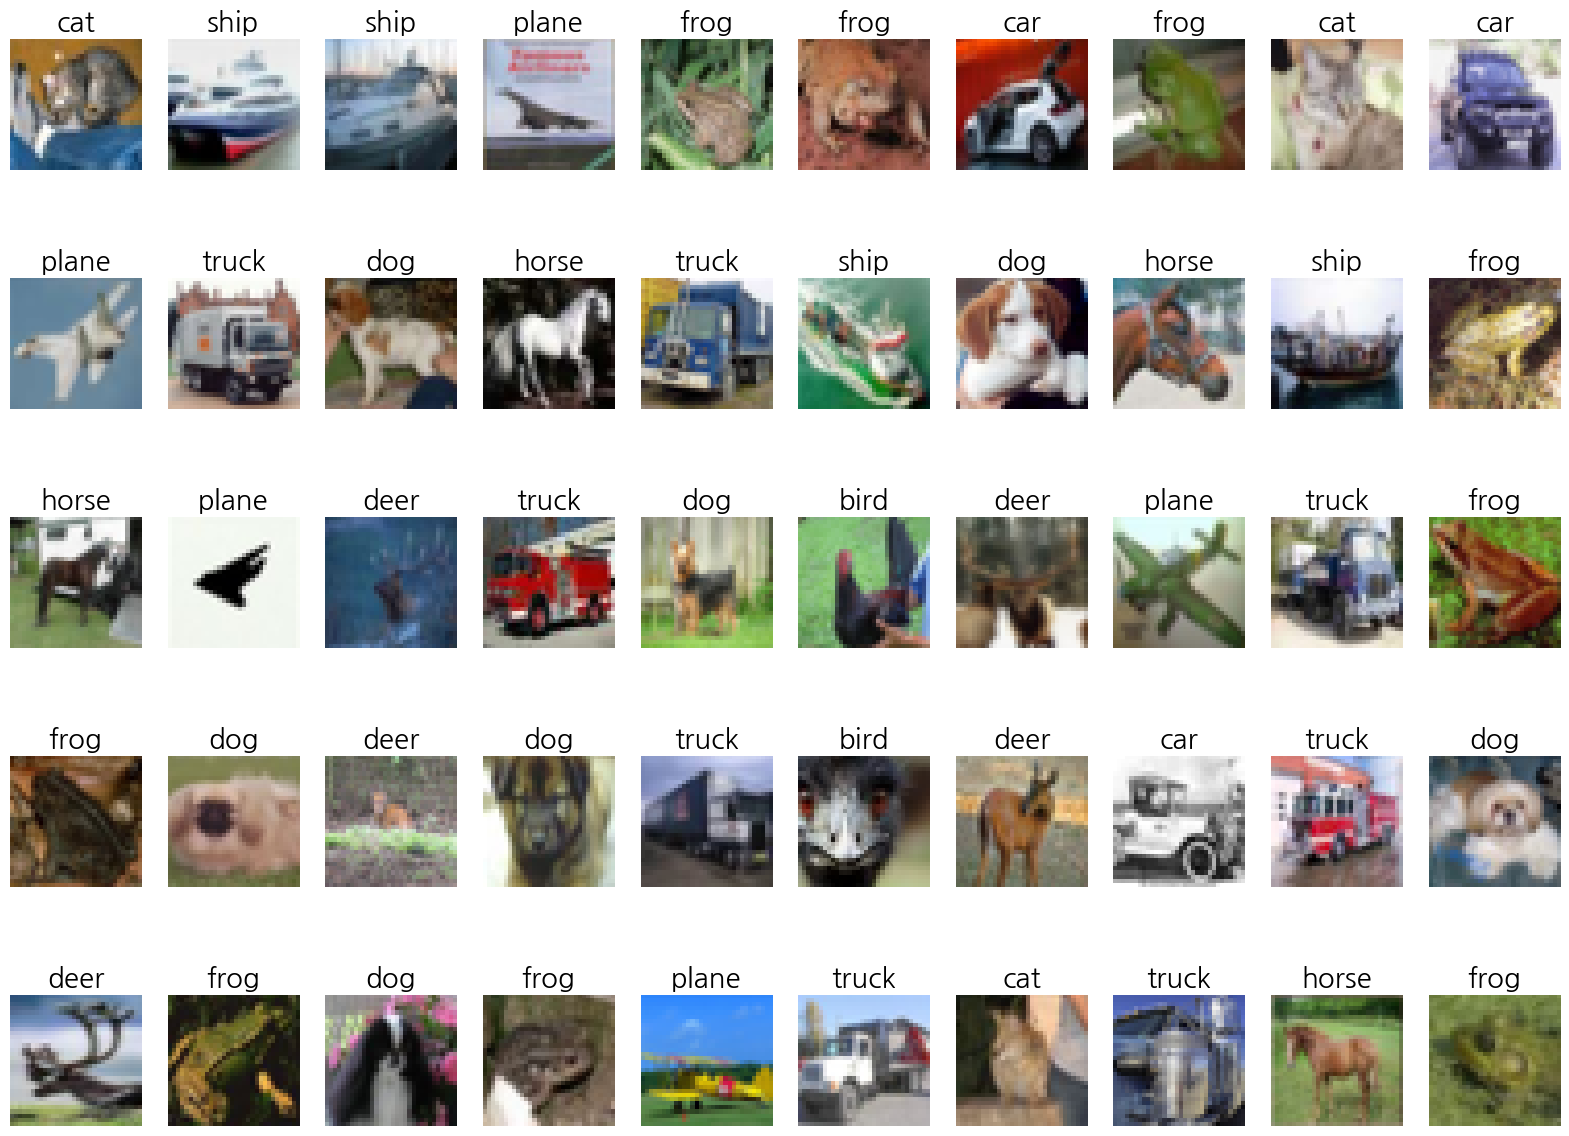

In [13]:
# 처음 50개 이미지 출력
show_images_labels(test_loader, classes, None, None)

## 층을 깊게 쌓은 모델 구현하기

In [14]:
class CNN_v2(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=(1,1))
        self.conv2 = nn.Conv2d(32, 32, 3, padding=(1,1))
        self.conv3 = nn.Conv2d(32, 64, 3, padding=(1,1))
        self.conv4 = nn.Conv2d(64, 64, 3, padding=(1,1))
        self.conv5 = nn.Conv2d(64, 128, 3, padding=(1,1))
        self.conv6 = nn.Conv2d(128, 128, 3, padding=(1,1))
        self.relu = nn.ReLU(inplace=True)
        self.flatten = nn.Flatten()
        self.maxpool = nn.MaxPool2d((2,2))
        self.l1 = nn.Linear(4*4*128, 128)
        self.l2 = nn.Linear(128, num_classes)

        self.features = nn.Sequential(
            self.conv1,
            self.relu,
            self.conv2,
            self.relu,
            self.maxpool,
            self.conv3,
            self.relu,
            self.conv4,
            self.relu,
            self.maxpool,
            self.conv5,
            self.relu,
            self.conv6,
            self.relu,
            self.maxpool,
            )

        self.classifier = nn.Sequential(
            self.l1,
            self.relu,
            self.l2
        )

    def forward(self, x):
        x1 = self.features(x)
        x2 = self.flatten(x1)
        x3 = self.classifier(x2)
        return x3

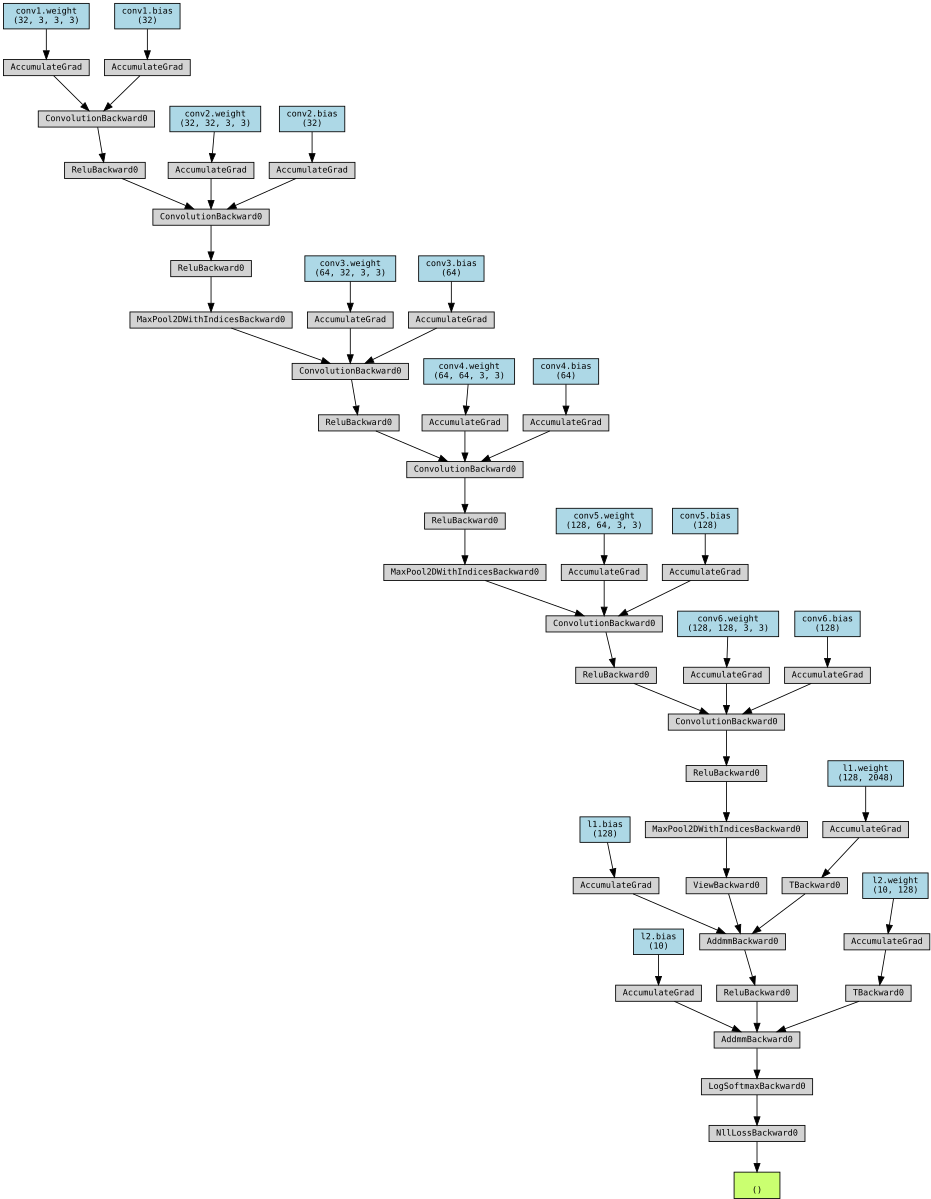

In [15]:
# 손실 계산 그래프 시각화
net = CNN_v2(n_output).to(device)
criterion = nn.CrossEntropyLoss()
loss = eval_loss(test_loader, device, net, criterion)
g = make_dot(loss, params=dict(net.named_parameters()))
display(g)

In [16]:
# 난수 고정
torch_seed()

# 모델 인스턴스 생성
lr = 0.01
net = CNN_v2(n_output).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=lr)
history = np.zeros((0, 5))

In [17]:
# 학습

num_epochs = 50
history = fit(net, optimizer, criterion, num_epochs, train_loader, test_loader, device, history)

  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [1/50], loss: 0.02303 acc: 0.10000 val_loss: 0.02303, val_acc: 0.10000


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [2/50], loss: 0.02303 acc: 0.10000 val_loss: 0.02303, val_acc: 0.10000


  0%|          | 0/500 [00:00<?, ?it/s]

...

Epoch [48/50], loss: 0.00379 acc: 0.86824 val_loss: 0.01048, val_acc: 0.69790


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [49/50], loss: 0.00348 acc: 0.87920 val_loss: 0.01061, val_acc: 0.70270


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [50/50], loss: 0.00318 acc: 0.88910 val_loss: 0.01101, val_acc: 0.69860


초기상태 : 손실 : 0.02303  정확도 : 0.10000
최종상태 : 손실 : 0.01101 정확도 : 0.69860


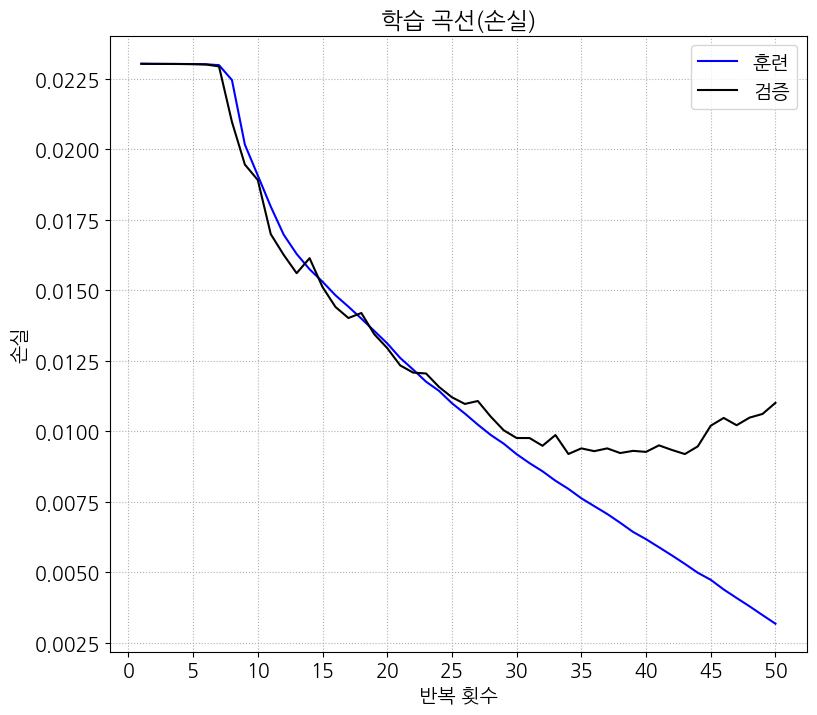

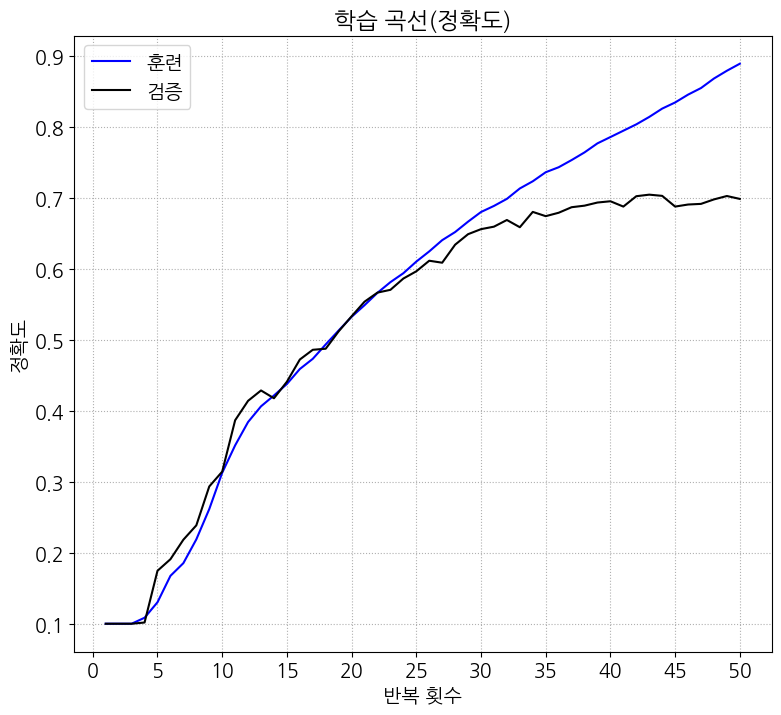

In [18]:
evaluate_history(history)

## 최적화 함수 선택

### 모멘텀 설정

In [19]:
# 난수 고정
torch_seed()

# 모델 인스턴스 생성
lr = 0.01
net = CNN_v2(n_output).to(device)
criterion = nn.CrossEntropyLoss()

# 최적화 함수에 모멘텀 값 설정
optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9)
history2 = np.zeros((0, 5))

In [20]:
# 학습

num_epochs = 20
history2 = fit(net, optimizer, criterion, num_epochs, train_loader, test_loader, device, history2)

  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [1/20], loss: 0.02286 acc: 0.12124 val_loss: 0.02051, val_acc: 0.24080


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [2/20], loss: 0.01800 acc: 0.33642 val_loss: 0.01524, val_acc: 0.42710


  0%|          | 0/500 [00:00<?, ?it/s]

...

Epoch [18/20], loss: 0.00104 acc: 0.96336 val_loss: 0.01188, val_acc: 0.76610


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [19/20], loss: 0.00096 acc: 0.96612 val_loss: 0.01390, val_acc: 0.75650


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [20/20], loss: 0.00088 acc: 0.96932 val_loss: 0.01271, val_acc: 0.76330


초기상태 : 손실 : 0.02051  정확도 : 0.24080
최종상태 : 손실 : 0.01271 정확도 : 0.76330


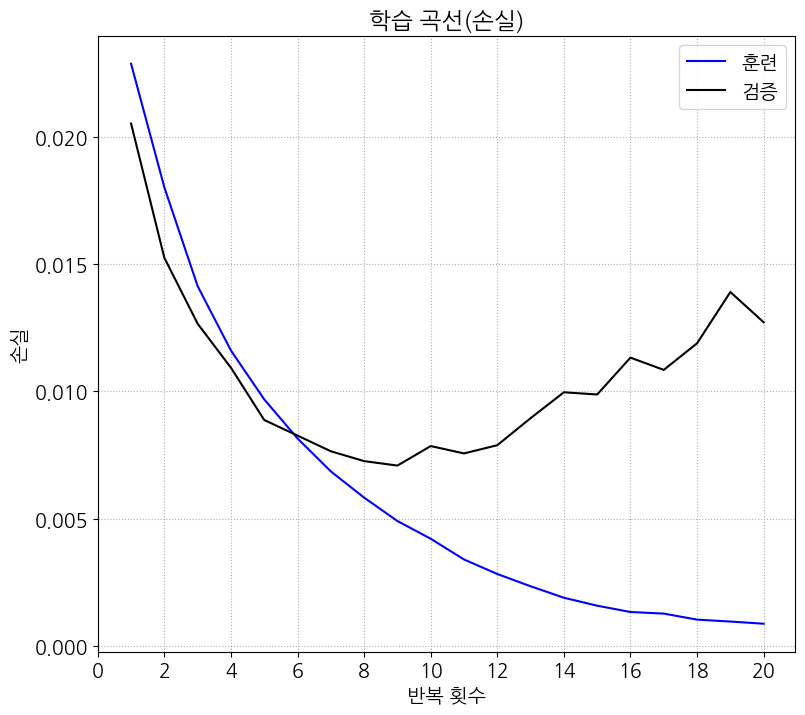

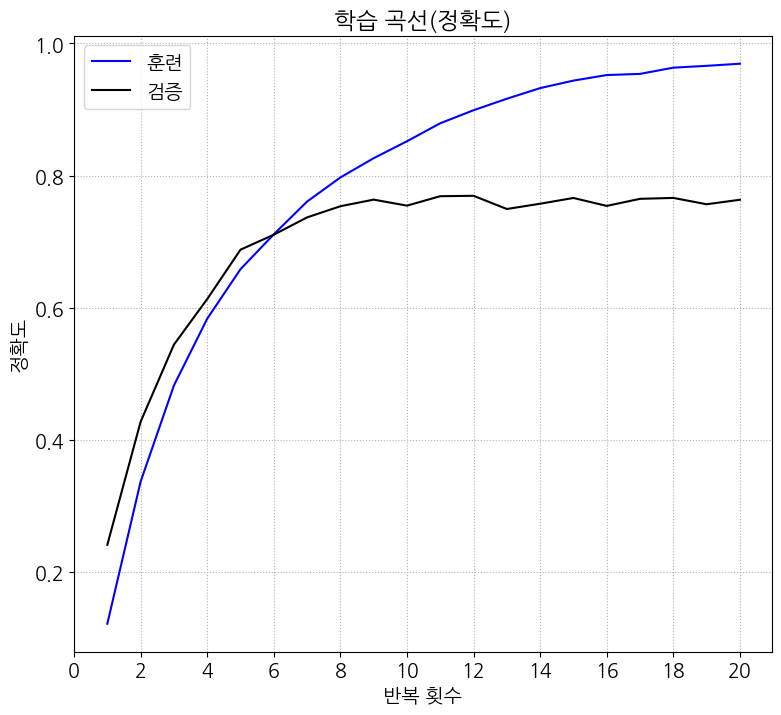

In [21]:
evaluate_history(history2)

### Adam 함수 사용

In [22]:
# 난수 고정
torch_seed()

# 모델 인스턴스 생성
net = CNN_v2(n_output).to(device)
criterion = nn.CrossEntropyLoss()

# 최적화 함수를 Adam으로 교체
optimizer = optim.Adam(net.parameters())
history3 = np.zeros((0, 5))

In [23]:
# 학습

num_epochs = 20
history3 = fit(net, optimizer, criterion, num_epochs, train_loader, test_loader, device, history3)

  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [1/20], loss: 0.01599 acc: 0.41138 val_loss: 0.01251, val_acc: 0.54530


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [2/20], loss: 0.01100 acc: 0.60582 val_loss: 0.01017, val_acc: 0.63780


  0%|          | 0/500 [00:00<?, ?it/s]

...

Epoch [18/20], loss: 0.00098 acc: 0.96628 val_loss: 0.01438, val_acc: 0.74470


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [19/20], loss: 0.00093 acc: 0.96794 val_loss: 0.01480, val_acc: 0.75860


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [20/20], loss: 0.00077 acc: 0.97378 val_loss: 0.01433, val_acc: 0.75310


초기상태 : 손실 : 0.01251  정확도 : 0.54530
최종상태 : 손실 : 0.01433 정확도 : 0.75310


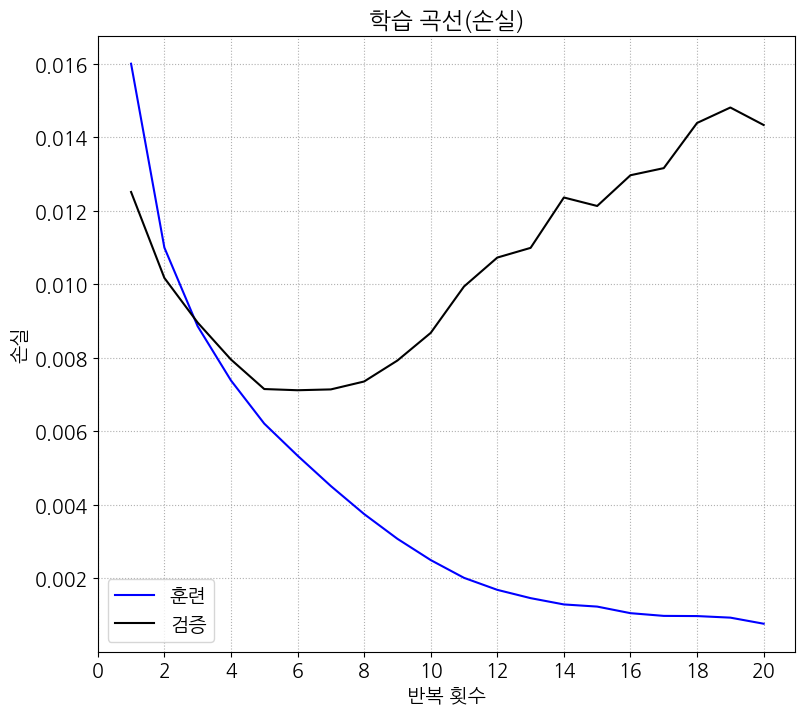

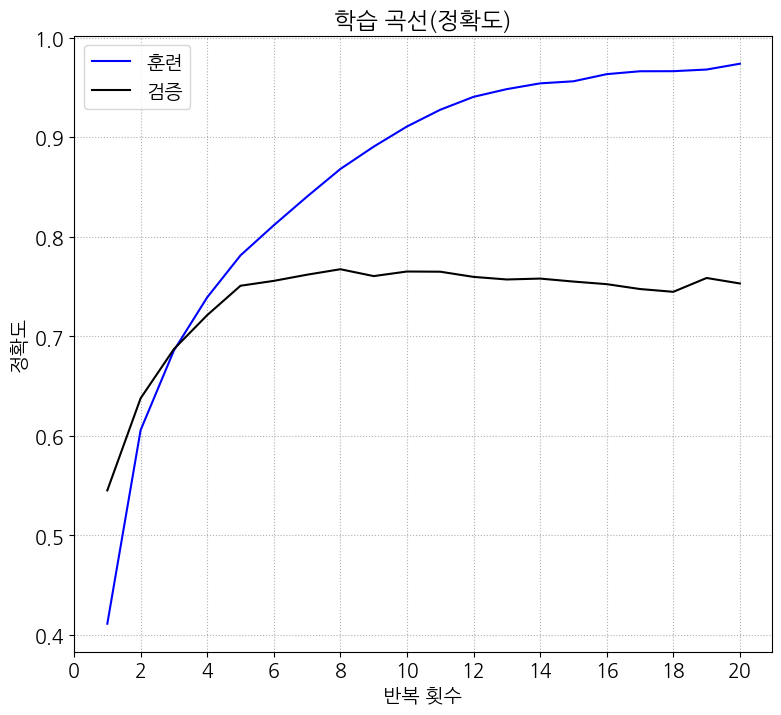

In [24]:
evaluate_history(history3)

### 결과 비교

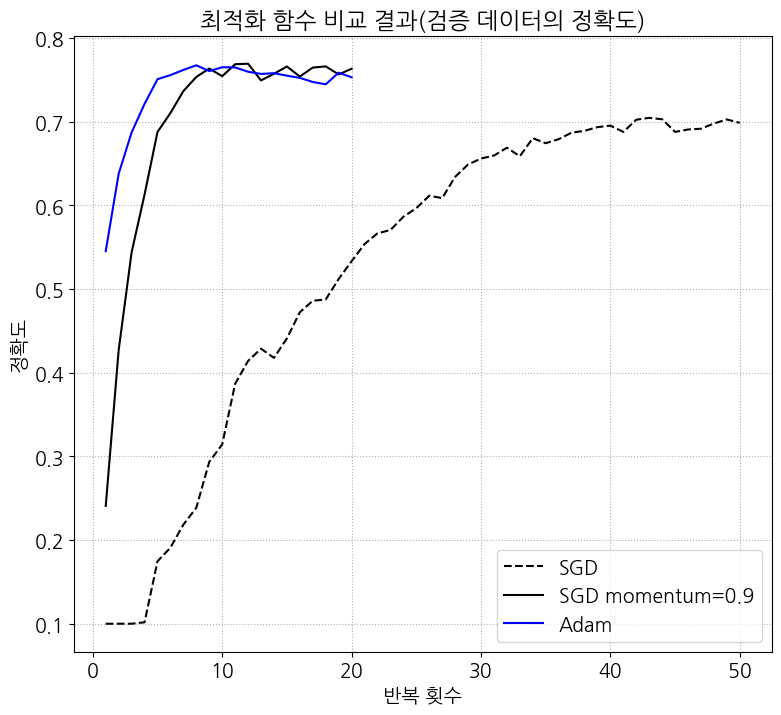

In [25]:
# 결과 비교(검증 데이터의 정확도)
plt.figure(figsize=(9,8))
plt.plot(history[:,0], history[:,4], label='SGD', c='k',ls='dashed' )
plt.plot(history2[:,0], history2[:,4], label='SGD momentum=0.9', c='k')
plt.plot(history3[:,0], history3[:,4], label='Adam', c='b')
plt.title('최적화 함수 비교 결과(검증 데이터의 정확도)')
plt.xlabel('반복 횟수')
plt.ylabel('정확도')
plt.legend()
plt.show()

## 드랍 아웃 (Dropout)

In [26]:
# 모델 정의

class CNN_v3(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=(1,1))
        self.conv2 = nn.Conv2d(32, 32, 3, padding=(1,1))
        self.conv3 = nn.Conv2d(32, 64, 3, padding=(1,1))
        self.conv4 = nn.Conv2d(64, 64, 3, padding=(1,1))
        self.conv5 = nn.Conv2d(64, 128, 3, padding=(1,1))
        self.conv6 = nn.Conv2d(128, 128, 3, padding=(1,1))
        self.relu = nn.ReLU(inplace=True)
        self.flatten = nn.Flatten()
        self.maxpool = nn.MaxPool2d((2,2))
        self.l1 = nn.Linear(4*4*128, 128)
        self.l2 = nn.Linear(128, 10)
        self.dropout1 = nn.Dropout(0.2)
        self.dropout2 = nn.Dropout(0.3)
        self.dropout3 = nn.Dropout(0.4)

        self.features = nn.Sequential(
            self.conv1,
            self.relu,
            self.conv2,
            self.relu,
            self.maxpool,
            self.dropout1,
            self.conv3,
            self.relu,
            self.conv4,
            self.relu,
            self.maxpool,
            self.dropout2,
            self.conv5,
            self.relu,
            self.conv6,
            self.relu,
            self.maxpool,
            self.dropout3,
            )

        self.classifier = nn.Sequential(
            self.l1,
            self.relu,
            self.dropout3,
            self.l2
        )

    def forward(self, x):
        x1 = self.features(x)
        x2 = self.flatten(x1)
        x3 = self.classifier(x2)
        return x3

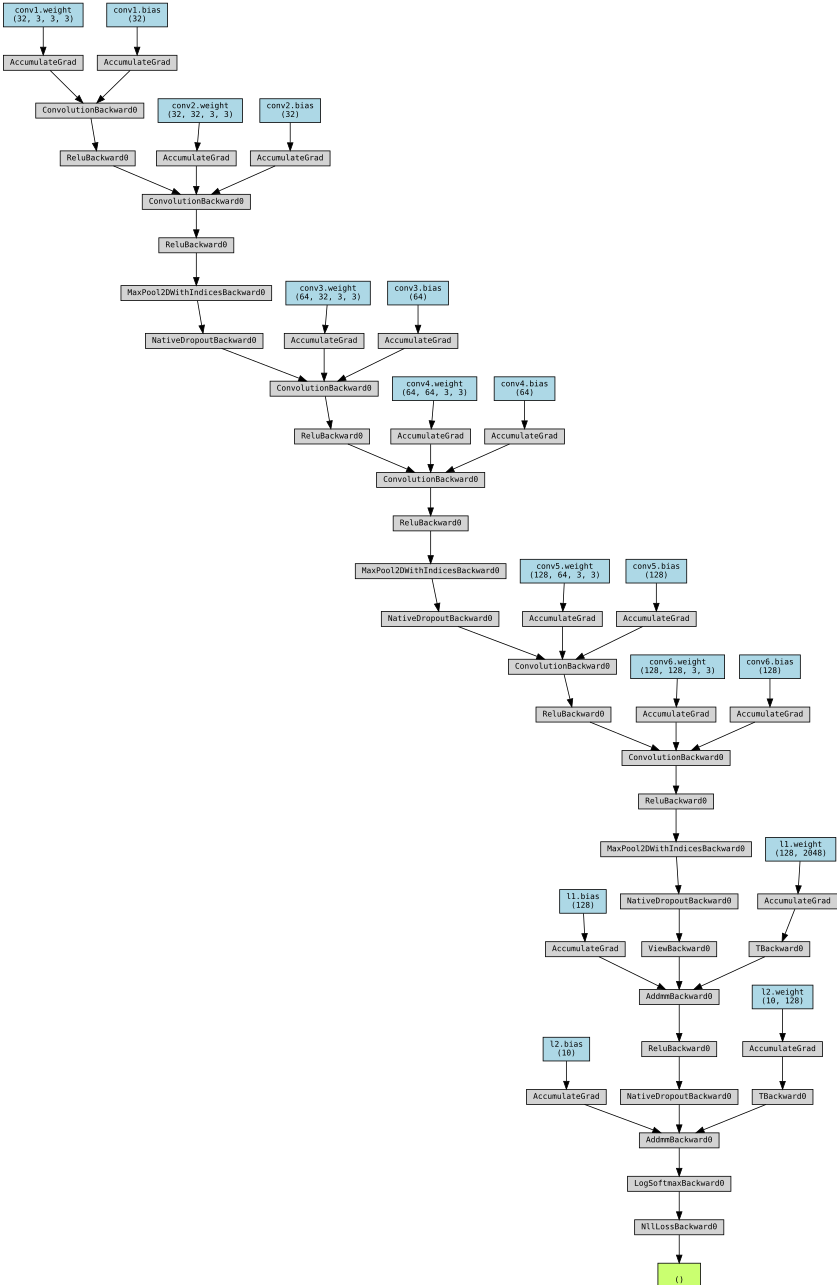

In [27]:
# 손실 계산 그래프 시각화
net = CNN_v3(n_output).to(device)
criterion = nn.CrossEntropyLoss()
loss = eval_loss(test_loader, device, net, criterion)
g = make_dot(loss, params=dict(net.named_parameters()))
display(g)

In [28]:
# 난수 고정
torch_seed()

# 모델 인스턴스 생성
net = CNN_v3(n_output).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters())
history = np.zeros((0, 5))

In [29]:
# 학습

num_epochs = 50
history = fit(net, optimizer, criterion, num_epochs, train_loader, test_loader, device, history)

  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [1/50], loss: 0.01706 acc: 0.36640 val_loss: 0.01291, val_acc: 0.52560


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [2/50], loss: 0.01274 acc: 0.53650 val_loss: 0.01046, val_acc: 0.62190


  0%|          | 0/500 [00:00<?, ?it/s]

...

Epoch [48/50], loss: 0.00395 acc: 0.86294 val_loss: 0.00555, val_acc: 0.83180


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [49/50], loss: 0.00393 acc: 0.86204 val_loss: 0.00535, val_acc: 0.83450


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [50/50], loss: 0.00390 acc: 0.86488 val_loss: 0.00531, val_acc: 0.83480


초기상태 : 손실 : 0.01291  정확도 : 0.52560
최종상태 : 손실 : 0.00531 정확도 : 0.83480


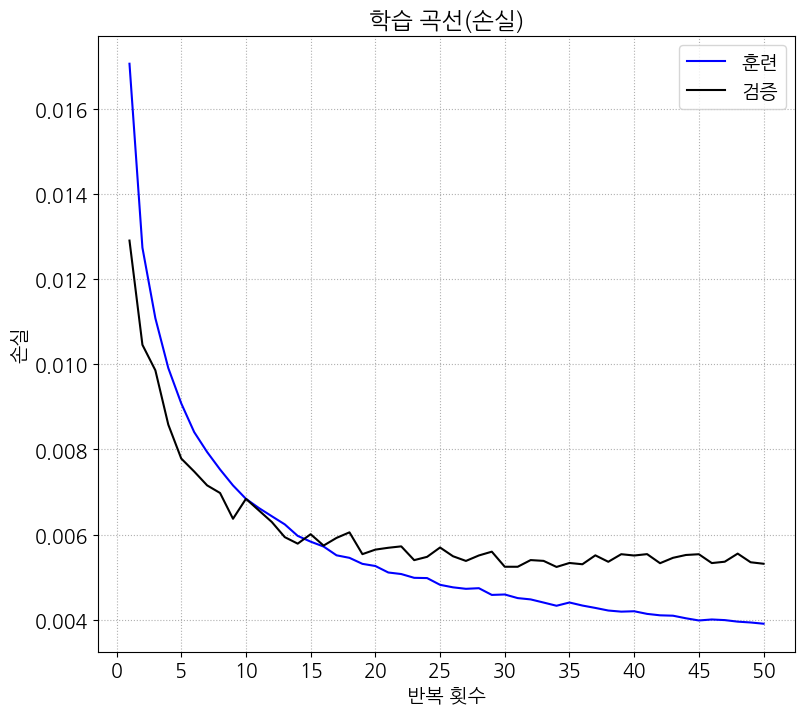

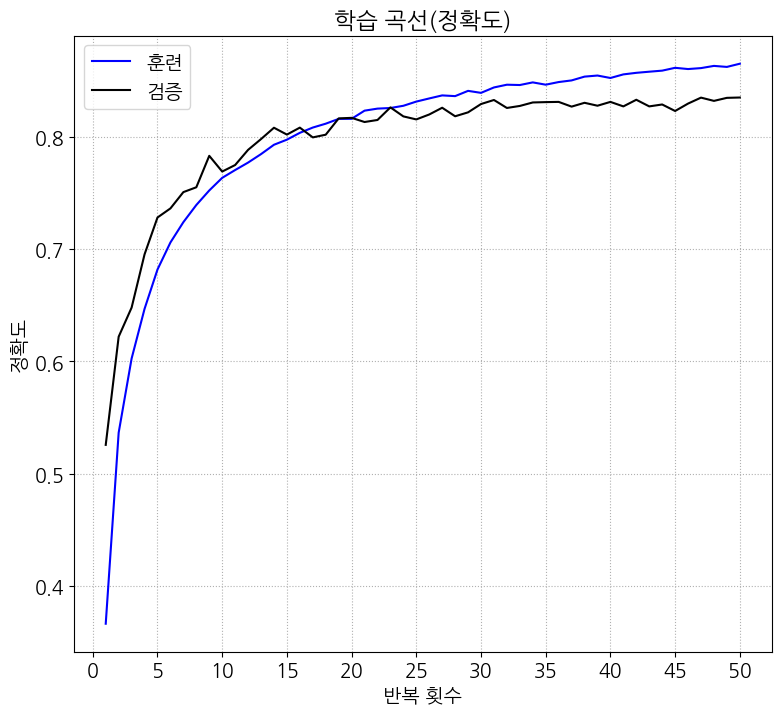

In [30]:
evaluate_history(history)

## 배치 정규화

In [31]:
class CNN_v4(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=(1,1))
        self.conv2 = nn.Conv2d(32, 32, 3, padding=(1,1))
        self.conv3 = nn.Conv2d(32, 64, 3, padding=(1,1))
        self.conv4 = nn.Conv2d(64, 64, 3, padding=(1,1))
        self.conv5 = nn.Conv2d(64, 128, 3, padding=(1,1))
        self.conv6 = nn.Conv2d(128, 128, 3, padding=(1,1))
        self.relu = nn.ReLU(inplace=True)
        self.flatten = nn.Flatten()
        self.maxpool = nn.MaxPool2d((2,2))
        self.l1 = nn.Linear(4*4*128, 128)
        self.l2 = nn.Linear(128, 10)
        self.dropout1 = nn.Dropout(0.2)
        self.dropout2 = nn.Dropout(0.3)
        self.dropout3 = nn.Dropout(0.4)
        self.bn1 = nn.BatchNorm2d(32)
        self.bn2 = nn.BatchNorm2d(32)
        self.bn3 = nn.BatchNorm2d(64)
        self.bn4 = nn.BatchNorm2d(64)
        self.bn5 = nn.BatchNorm2d(128)
        self.bn6 = nn.BatchNorm2d(128)

        self.features = nn.Sequential(
            self.conv1,
            self.bn1,
            self.relu,
            self.conv2,
            self.bn2,
            self.relu,
            self.maxpool,
            self.dropout1,
            self.conv3,
            self.bn3,
            self.relu,
            self.conv4,
            self.bn4,
            self.relu,
            self.maxpool,
            self.dropout2,
            self.conv5,
            self.bn5,
            self.relu,
            self.conv6,
            self.bn6,
            self.relu,
            self.maxpool,
            self.dropout3,
            )

        self.classifier = nn.Sequential(
            self.l1,
            self.relu,
            self.dropout3,
            self.l2
        )

    def forward(self, x):
        x1 = self.features(x)
        x2 = self.flatten(x1)
        x3 = self.classifier(x2)
        return x3

In [32]:
# 난수 고정
torch_seed(1234)

# 모델 인스턴스 생성
net = CNN_v4(n_output).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters())
history = np.zeros((0, 5))

In [33]:
# 학습

num_epochs = 50
history = fit(net, optimizer, criterion, num_epochs, train_loader, test_loader, device, history)

  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [1/50], loss: 0.01528 acc: 0.43470 val_loss: 0.01214, val_acc: 0.55300


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [2/50], loss: 0.01144 acc: 0.59318 val_loss: 0.00939, val_acc: 0.66280


  0%|          | 0/500 [00:00<?, ?it/s]

...

Epoch [48/50], loss: 0.00259 acc: 0.91300 val_loss: 0.00453, val_acc: 0.86730


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [49/50], loss: 0.00254 acc: 0.91284 val_loss: 0.00451, val_acc: 0.86760


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [50/50], loss: 0.00254 acc: 0.91330 val_loss: 0.00471, val_acc: 0.86690


초기상태 : 손실 : 0.01214  정확도 : 0.55300
최종상태 : 손실 : 0.00471 정확도 : 0.86690


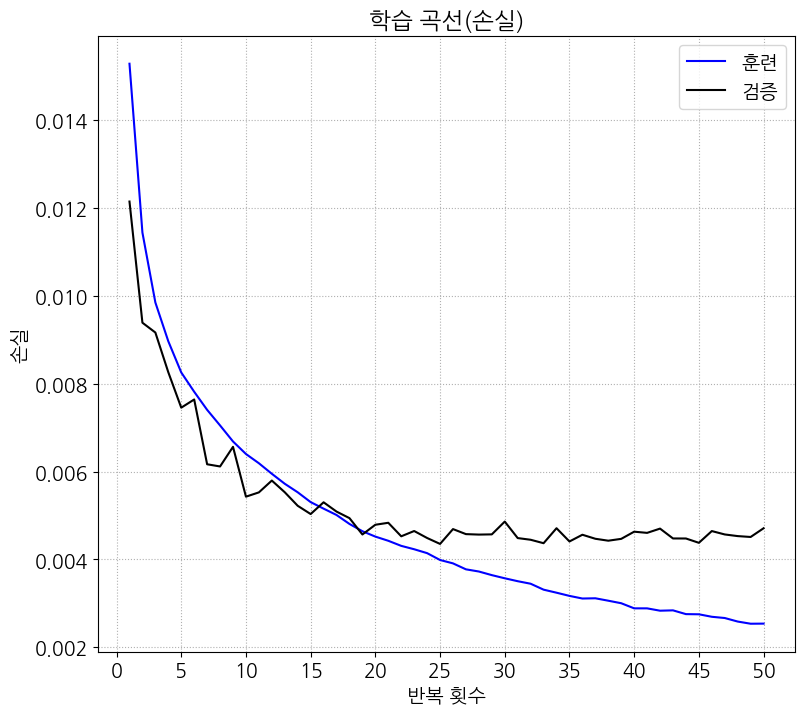

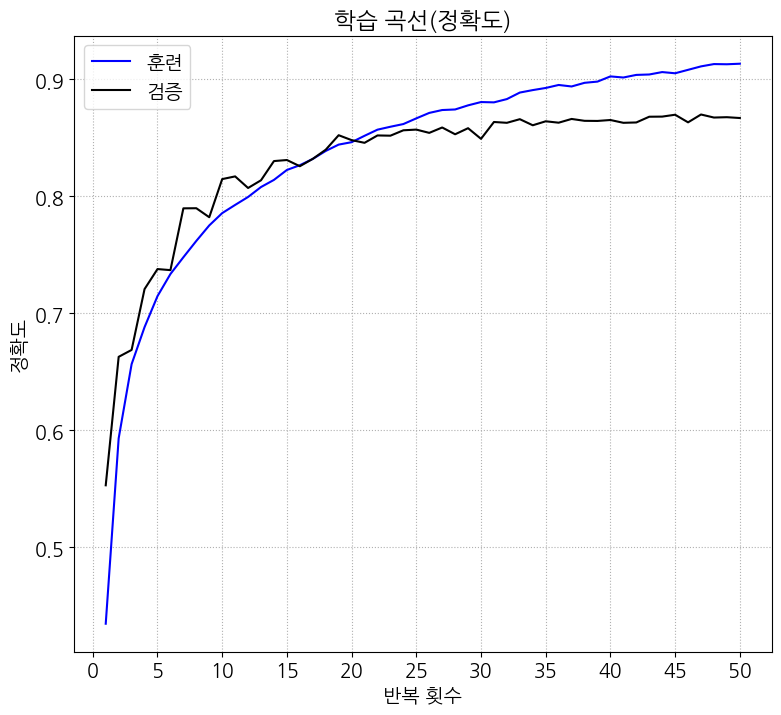

In [34]:
evaluate_history(history)

## 데이터 증강 기법

In [35]:
# 훈련 데이터용: 정규화에 반전과 RandomErasing 추가
transform_train = transforms.Compose([
  transforms.RandomHorizontalFlip(p=0.5), # 랜덤으로 좌우 반전
  transforms.RandomRotation(30),  # 랜덤으로 -30~30도 회전
  transforms.ColorJitter(brightness=0.5, contrast=0.5),  # 밝기, 대비 조절
  transforms.ToTensor(),
  transforms.Normalize(0.5, 0.5),
  transforms.RandomErasing(p=0.5, scale=(0.02, 0.33), ratio=(0.3, 3.3), value=0, inplace=False)
])

# class RandomErasing(
#     p: float = 0.5, # Probability that the Random Erasing operation will be performed.
#     scale: Any = (0.02, 0.33), # Range of proportion of erased area against the input image area.
#     ratio: Any = (0.3, 3.3), # Aspect ratio range of the erased rectangle.
#     value: int = 0,
#     inplace: bool = False
# )

In [36]:
# transfrom_train을 사용한 데이터셋 정의
train_set2 = datasets.CIFAR10(
    root = data_root,
    train = True,
    download = True,
    transform = transform_train) # n = 50000

# traisform_train을 사용한 데이터로더 정의
batch_size = 100
train_loader2 = DataLoader(train_set2, batch_size=batch_size, shuffle=True)

Files already downloaded and verified


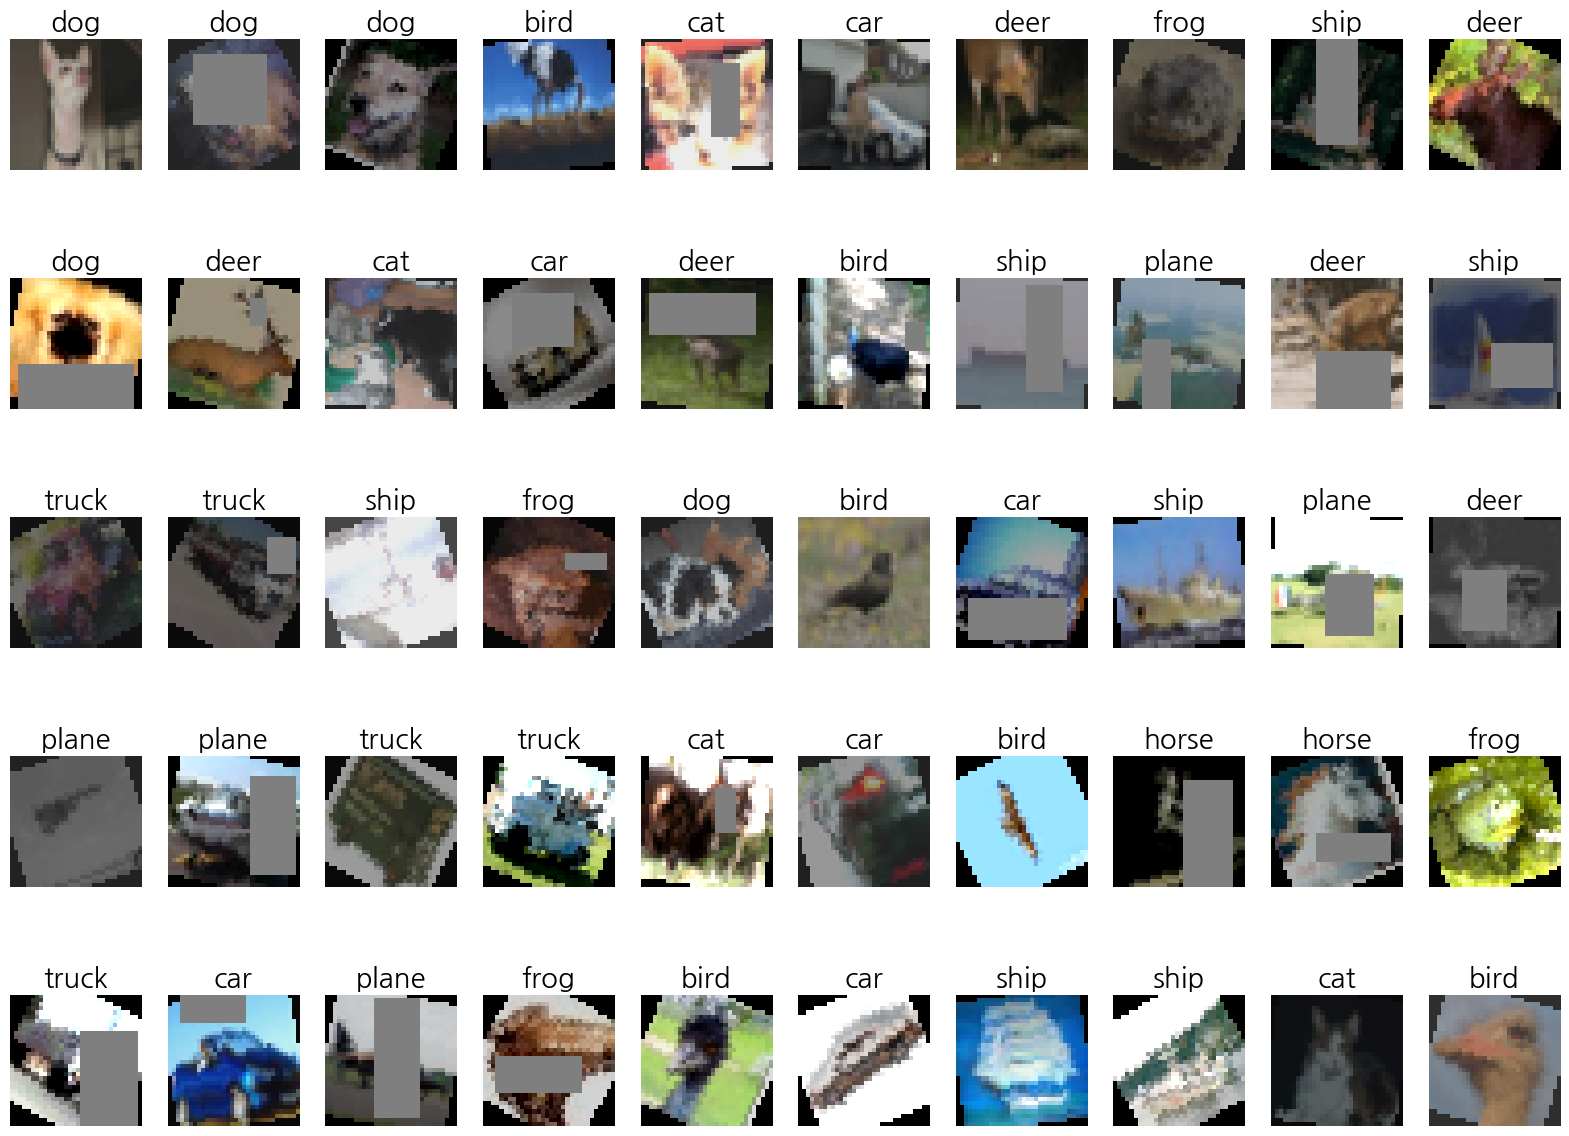

In [37]:
# 새로운 훈련 데이터의 처음 50개 표시

# 난수 고정
# torch_seed(12345)

show_images_labels(train_loader2, classes, None, None)

In [38]:
# 난수 고정
torch_seed()

# 모델 인스턴스 생성
net = CNN_v4(n_output).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters())
history = np.zeros((0, 5))

In [ ]:
# 학습
# 동일한 모델에서 train_loader2로 데이터를 변경

num_epochs = 100
history = fit(net, optimizer, criterion, num_epochs,
        train_loader2, test_loader, device, history)

  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [1/100], loss: 0.01909 acc: 0.28624 val_loss: 0.01492, val_acc: 0.43330


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [2/100], loss: 0.01633 acc: 0.39462 val_loss: 0.01272, val_acc: 0.53950


  0%|          | 0/500 [00:00<?, ?it/s]

...

Epoch [98/100], loss: 0.00706 acc: 0.75904 val_loss: 0.00438, val_acc: 0.85440


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [99/100], loss: 0.00710 acc: 0.75758 val_loss: 0.00448, val_acc: 0.84800


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [100/100], loss: 0.00698 acc: 0.76160 val_loss: 0.00426, val_acc: 0.85370


초기상태 : 손실 : 0.01492  정확도 : 0.43330
최종상태 : 손실 : 0.00426 정확도 : 0.85370


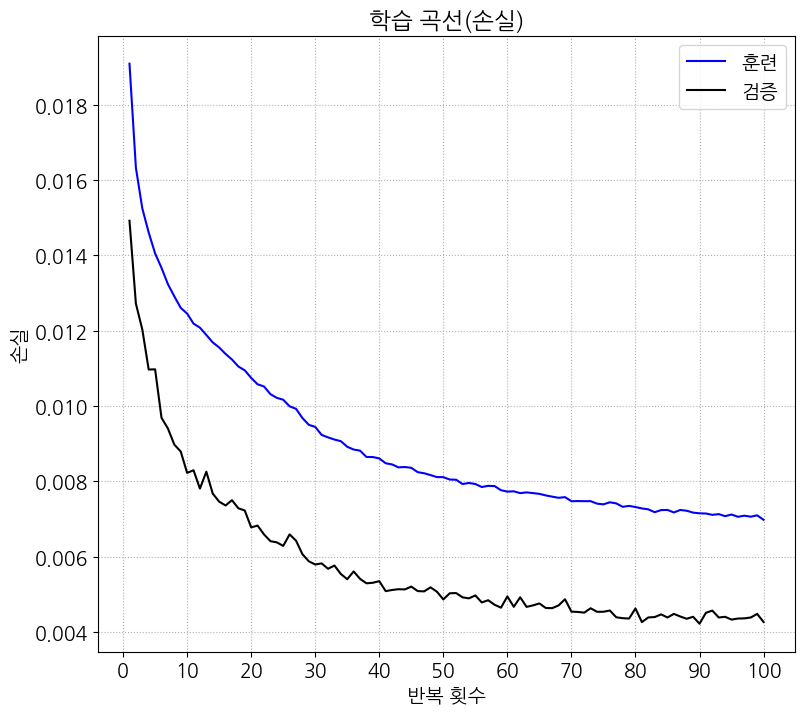

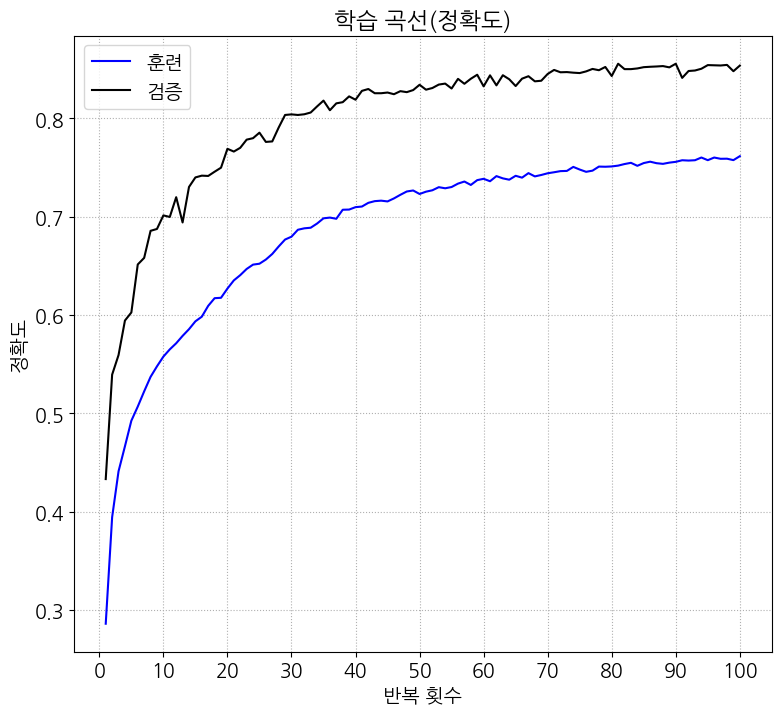

In [ ]:
evaluate_history(history)

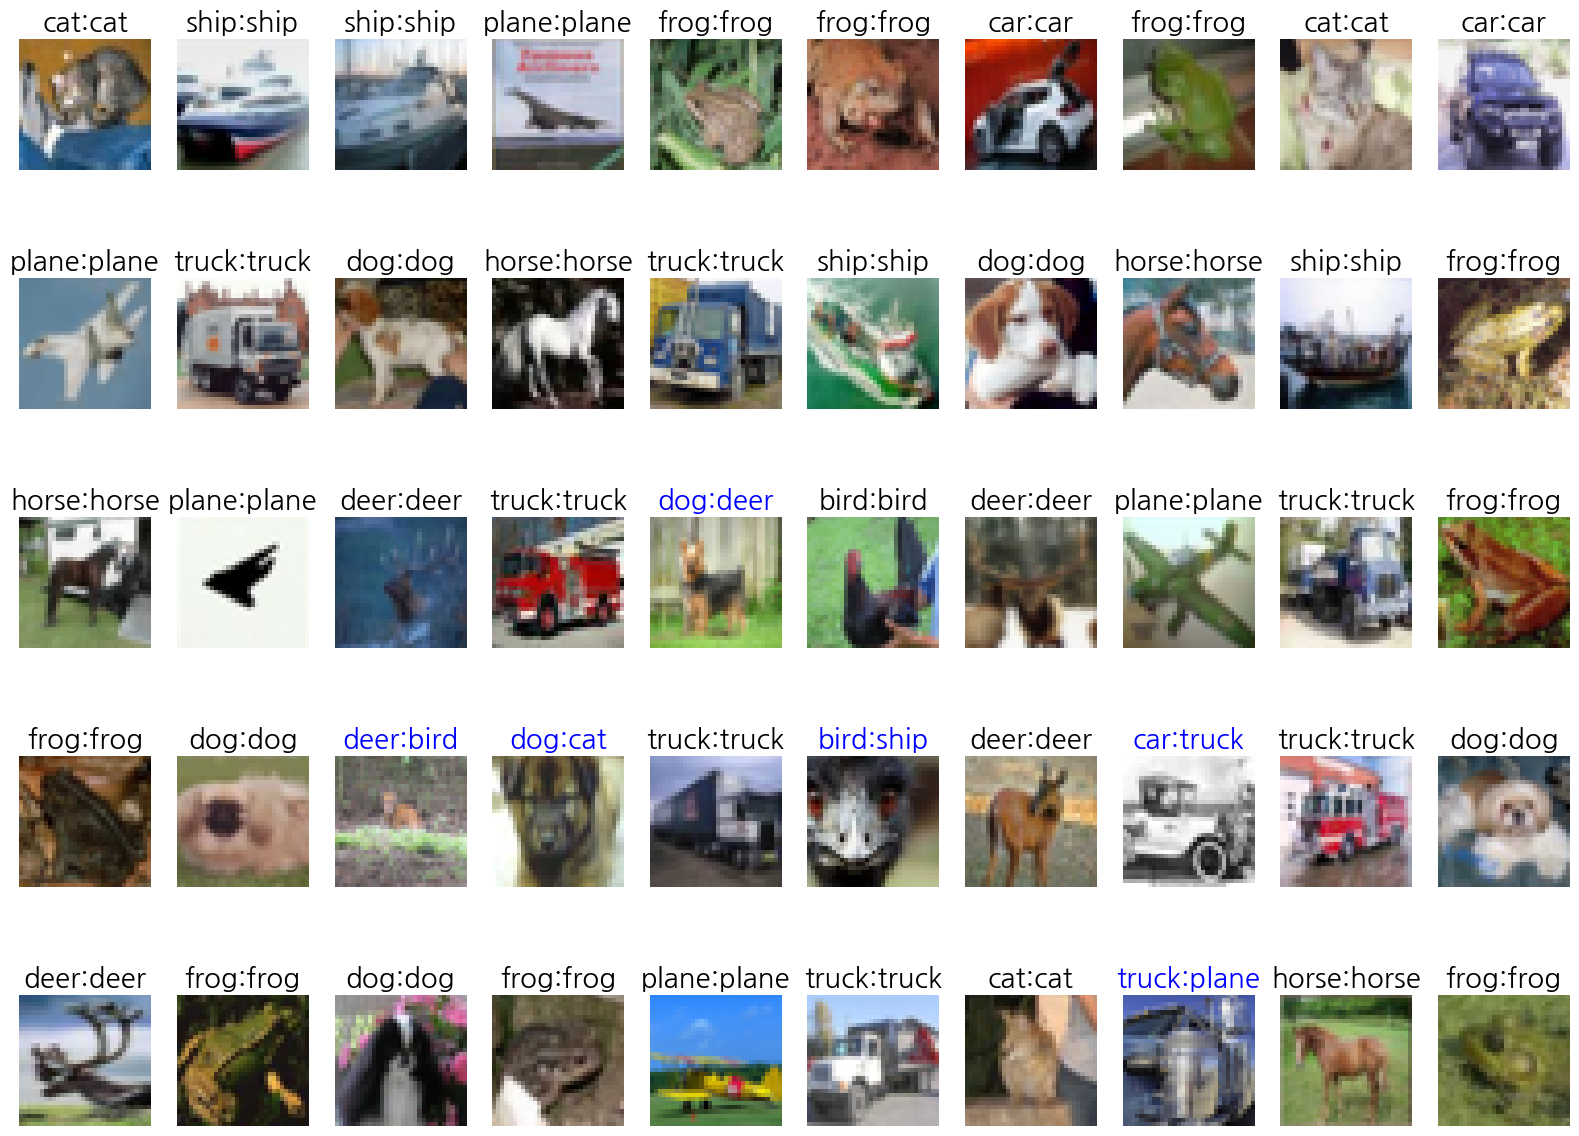

In [ ]:
show_images_labels(test_loader, classes, net, device)

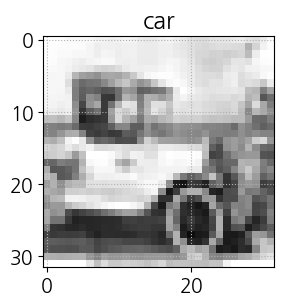

In [ ]:
# 잘못 예측한 38번째 데이터 추출
for images, labels in test_loader:
    break
image = images[37]
label = labels[37]

# 이미지 확인
plt.figure(figsize=(3,3))
w = image.numpy().copy()
w2 = np.transpose(w, (1, 2, 0))
w3 = (w2 + 1)/2
plt.title(classes[label])
plt.imshow(w3)
plt.show()

In [ ]:
# 예측 값 출력
image = image.view(1, 3, 32, 32)
image = image.to(device)
output = net(image)

# 라벨 별 확률 값 출력
probs = torch.softmax(output, dim=1)
probs_np = probs.data.to('cpu').numpy()[0]
print(probs_np)
values = np.frompyfunc(lambda x: f'{x:.04f}', 1, 1)(probs_np)
values
names = np.array(classes)
tbl = np.array([names, values]).T
tbl

[0.0002 0.4003 0.0001 0.0003 0.     0.0006 0.     0.     0.0015 0.5971]


array([['plane', '0.0002'],
       ['car', '0.4003'],
       ['bird', '0.0001'],
       ['cat', '0.0003'],
       ['deer', '0.0000'],
       ['dog', '0.0006'],
       ['frog', '0.0000'],
       ['horse', '0.0000'],
       ['ship', '0.0015'],
       ['truck', '0.5971']], dtype=object)

## 칼럼 배치 정규화를 사용할 때 주의할 점

### 잘못된 모델 클래스 정의의 예시

In [ ]:
class CNN_v5(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=(1,1))
        self.conv2 = nn.Conv2d(32, 32, 3, padding=(1,1))
        self.conv3 = nn.Conv2d(32, 64, 3, padding=(1,1))
        self.conv4 = nn.Conv2d(64, 64, 3, padding=(1,1))
        self.conv5 = nn.Conv2d(64, 128, 3, padding=(1,1))
        self.conv6 = nn.Conv2d(128, 128, 3, padding=(1,1))
        self.relu = nn.ReLU(inplace=True)
        self.flatten = nn.Flatten()
        self.maxpool = nn.MaxPool2d((2,2))
        self.l1 = nn.Linear(4*4*128, 128)
        self.l2 = nn.Linear(128, 10)
        self.dropout1 = nn.Dropout(0.2)
        self.dropout2 = nn.Dropout(0.3)
        self.dropout3 = nn.Dropout(0.4)
        self.bn1 = nn.BatchNorm2d(32)
        self.bn2 = nn.BatchNorm2d(64)
        self.bn3 = nn.BatchNorm2d(128)

        self.features = nn.Sequential(
            self.conv1,
            self.bn1,
            self.relu,
            self.conv2,
            self.bn1,
            self.relu,
            self.maxpool,
            self.dropout1,
            self.conv3,
            self.bn2,
            self.relu,
            self.conv4,
            self.bn2,
            self.relu,
            self.maxpool,
            self.dropout2,
            self.conv5,
            self.bn3,
            self.relu,
            self.conv6,
            self.bn3,
            self.relu,
            self.maxpool,
            self.dropout3,
            )

        self.classifier = nn.Sequential(
            self.l1,
            self.relu,
            self.dropout3,
            self.l2
        )

    def forward(self, x):
        x1 = self.features(x)
        x2 = self.flatten(x1)
        x3 = self.classifier(x2)
        return x3

In [ ]:
# 난수 고정
torch_seed()

# 모델 인스턴스 생성
net = CNN_v5(n_output).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters())
history = np.zeros((0, 5))

In [ ]:
# 학습

num_epochs = 50
history = fit(net, optimizer, criterion, num_epochs, train_loader, test_loader, device, history)

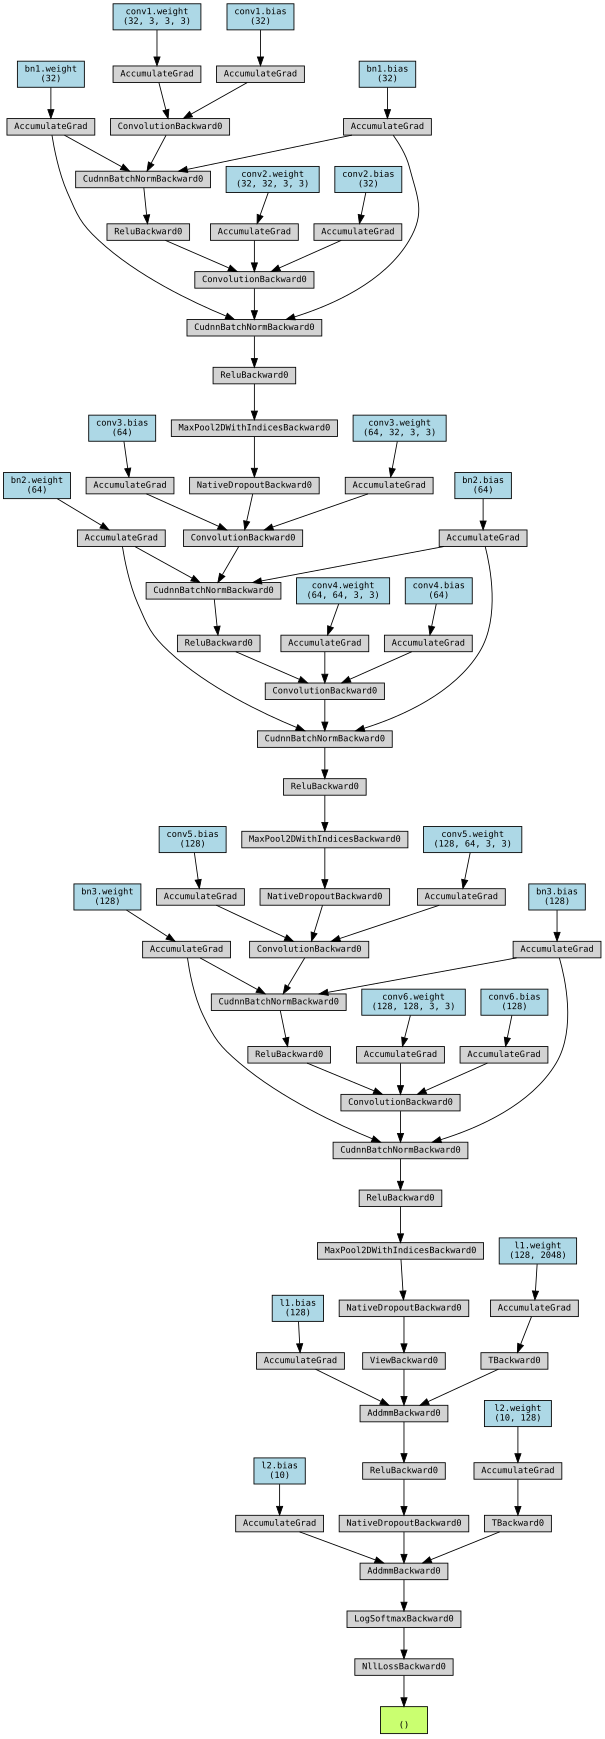

In [ ]:
# 손실 계산 그래프 시각화
net = CNN_v5(n_output).to(device)
criterion = nn.CrossEntropyLoss()
loss = eval_loss(test_loader, device, net, criterion)
g = make_dot(loss, params=dict(net.named_parameters()))
display(g)

## 칼럼 배치 정규화에서 처리하는 내용

In [ ]:
# 입력용 더미 데이터 작성

torch.manual_seed(123)
inputs = torch.randn(1, 1, 10)
print(inputs)

tensor([[[-0.1115,  0.1204, -0.3696, -0.2404, -1.1969,  0.2093, -0.9724,
          -0.7550,  0.3239, -0.1085]]])


In [ ]:
# 입력 미니 배치 데이터의 통계량 산출

i_mean = inputs.mean()
i_var = inputs.var(unbiased=True)
i_std = inputs.std(unbiased=False)
print(i_mean, i_std, i_var)

tensor(-0.3101) tensor(0.4867) tensor(0.2632)


In [ ]:
# BN 함수의 정의

bn = nn.BatchNorm1d(1)
print(bn.running_mean) # 러닝 평균 (배치 평균의 지수 이동 평균)
print(bn.running_var) # 러닝 분산 (배치 분산의 지수 이동 평균)
print(bn.weight.data) # 배치 정규화 스케일링
print(bn.bias.data) # 배치 정규화 이동

tensor([0.])
tensor([1.])
tensor([1.])
tensor([0.])


In [ ]:
# BN 함수의 유사 호출

bn.train()
print('===훈련 페이즈 1===')
outputs1 = bn(inputs)
print(outputs1.data)
print(bn.running_mean)
print(bn.running_var)

bn.eval()
print('===예측 페이즈 1===')
outputs2 = bn(inputs)
print(outputs2.data)
print(bn.running_mean)
print(bn.running_var)

bn.train()
print('===훈련 페이즈 2===')
outputs3 = bn(inputs)
print(outputs3.data)
print(bn.running_mean)
print(bn.running_var)

bn.eval()
print('===예측 페이즈 2===')
outputs4 = bn(inputs)
print(outputs4.data)
print(bn.running_mean)
print(bn.running_var)


===훈련 페이즈 1===
tensor([[[ 0.4081,  0.8844, -0.1224,  0.1431, -1.8222,  1.0671, -1.3608,
          -0.9143,  1.3027,  0.4142]]])
tensor([-0.0310])
tensor([0.9263])
===예측 페이즈 1===
tensor([[[-0.0836,  0.1573, -0.3518, -0.2176, -1.2114,  0.2496, -0.9781,
          -0.7523,  0.3688, -0.0805]]])
tensor([-0.0310])
tensor([0.9263])
===훈련 페이즈 2===
tensor([[[ 0.4081,  0.8844, -0.1224,  0.1431, -1.8222,  1.0671, -1.3608,
          -0.9143,  1.3027,  0.4142]]])
tensor([-0.0589])
tensor([0.8600])
===예측 페이즈 2===
tensor([[[-0.0567,  0.1933, -0.3351, -0.1957, -1.2271,  0.2892, -0.9850,
          -0.7507,  0.4128, -0.0535]]])
tensor([-0.0589])
tensor([0.8600])


In [ ]:
# 훈련 페이즈의 출력

xt = (inputs - i_mean)/i_std * bn.weight + bn.bias
print(xt.data)

print(outputs1.data)

tensor([[[ 0.4081,  0.8845, -0.1224,  0.1431, -1.8223,  1.0671, -1.3608,
          -0.9143,  1.3027,  0.4142]]])
tensor([[[ 0.4081,  0.8844, -0.1224,  0.1431, -1.8222,  1.0671, -1.3608,
          -0.9143,  1.3027,  0.4142]]])


In [ ]:
# 예측 페이즈의 출력

xp = (inputs-bn.running_mean)/torch.sqrt(bn.running_var)
print(xp.data)

print(outputs4.data)

tensor([[[-0.0567,  0.1933, -0.3351, -0.1957, -1.2271,  0.2892, -0.9850,
          -0.7507,  0.4128, -0.0535]]])
tensor([[[-0.0567,  0.1933, -0.3351, -0.1957, -1.2271,  0.2892, -0.9850,
          -0.7507,  0.4128, -0.0535]]])


In [ ]:
# running_mean과 runnung_var의 계산식

# 초깃값
mean0 = 0
var0 = 1
momentum = bn.momentum
print("momentum = ", momentum)
# 이동 평균 계산 1회차
mean1 = (1-momentum) * mean0 +  momentum * i_mean
var1 = (1-momentum) * var0 +  momentum * i_var
print(mean1, var1)

# 이동 평균 계산 2회차
mean2 = (1-momentum) * mean1 +  momentum * i_mean
var2 = (1-momentum) * var1 +  momentum * i_var
print(mean2, var2)